# COMP 3610: Big Data Analytics - Assignment 4
## MLOps & Model Deployment

**Student ID:** 81640879

# Part 0: Environment Setup & Data Preparation

## 0.1 Install Dependencies

All required packages are installed from `requirements.txt` before any imports.

In [ ]:
pip install -r requirements.txt

Verify all required packages are installed and print versions in `requirements.txt` format.
This output can be used directly to build or validate `requirements.txt`.

In [3]:
import importlib

pkgs = [
   "numpy", "pandas", "sklearn",
     "seaborn", "skops", "requests", "pyarrow",
    "mlflow", "fastapi", "uvicorn", "pydantic", "httpx", "joblib",
]

print("Package Versions")
print("-" * 30)
for pkg_name in pkgs:
    try:
        mod = importlib.import_module(pkg_name)
        ver = getattr(mod, "__version__", "n/a")
        print(f"{pkg_name}=={ver}")
    except Exception as e:
        print(f"{pkg_name:<15} NOT FOUND")
print("-" * 30)

Package Versions
------------------------------
numpy==2.3.2
pandas==2.3.1
sklearn==1.8.0
seaborn==0.13.2
skops==0.13.0
requests==2.33.0
pyarrow==18.1.0
mlflow==3.10.1
fastapi==0.135.3
uvicorn==0.42.0
pydantic==2.12.5
httpx==0.28.1
joblib==1.5.3
------------------------------


## 0.2 Imports and Global Configuration

Every library used throughout this notebook is imported here. The global random seed ensures all stochastic operations are reproducible.

In [ ]:
from pathlib import Path
from datetime import datetime

import requests
import numpy as np
import pandas as pd


from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow
from mlflow.tracking import MlflowClient

SEED   = 42
EPOCHS = 20
np.random.seed(SEED)






## 0.3 Download Data

Downloads the NYC Yellow Taxi January 2024 parquet file and zone lookup CSV. The download is skipped if the file already exists.

In [5]:
TRIP_URL  = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
ZONE_URL  = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

RAW_DIR    = Path("data/raw")
TRIP_PATH  = RAW_DIR / "yellow_tripdata_2024-01.parquet"
ZONE_PATH  = RAW_DIR / "taxi_zone_lookup.csv"


def download_file(url: str, dest: Path, chunk: int = 8192) -> bool:
    try:
        dest.parent.mkdir(parents=True, exist_ok=True)
        r = requests.get(url, stream=True, timeout=60)
        r.raise_for_status()
        total, done = int(r.headers.get("content-length", 0)), 0
        with open(dest, "wb") as f:
            for block in r.iter_content(chunk_size=chunk):
                if block:
                    f.write(block)
                    done += len(block)
                    if total:
                        print(f"\r  {done/total*100:5.1f}%  [{done//(1024**2)} MB]", end="")
        print(f"\n  saved -> {dest.name}  ({done/(1024**2):.1f} MB)")
        return True
    except Exception as err:
        print(f"  failed: {err}")
        return False


if not TRIP_PATH.exists():
    print("Downloading trip data...")
    download_file(TRIP_URL, TRIP_PATH)

if not ZONE_PATH.exists():
    print("Downloading zone lookup...")
    download_file(ZONE_URL, ZONE_PATH)

print("Data files ready.")

Data files ready.


## 0.4 Load Raw Data

Loads the parquet file and zone lookup into pandas DataFrames.

In [6]:
raw_df   = pd.read_parquet(TRIP_PATH)
zones_df = pd.read_csv(ZONE_PATH)

print(f"  trip records : {len(raw_df):>10,}")
print(f"  trip columns : {raw_df.shape[1]:>10}")
print(f"  zone records : {len(zones_df):>10,}")
raw_df.head()

  trip records :  2,964,624
  trip columns :         19
  zone records :        265


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0000,1.7200,1.0000,N,186,79,2,17.7000,1.0000,0.5000,0.0000,0.0000,1.0000,22.7000,2.5000,0.0000
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0000,1.8000,1.0000,N,140,236,1,10.0000,3.5000,0.5000,3.7500,0.0000,1.0000,18.7500,2.5000,0.0000
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0000,4.7000,1.0000,N,236,79,1,23.3000,3.5000,0.5000,3.0000,0.0000,1.0000,31.3000,2.5000,0.0000
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0000,1.4000,1.0000,N,79,211,1,10.0000,3.5000,0.5000,2.0000,0.0000,1.0000,17.0000,2.5000,0.0000
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0000,0.8000,1.0000,N,211,148,1,7.9000,3.5000,0.5000,3.2000,0.0000,1.0000,16.1000,2.5000,0.0000


## 0.5 Data Cleaning

Applies the same pipeline from Assignment 2. Only credit card payments are kept because tip amounts are reliably recorded only for those transactions.

In [7]:
def clean_trip_data(df: pd.DataFrame) -> pd.DataFrame:
    n0 = len(df)
    steps = []

    df = df[df["payment_type"] == 1].copy()
    steps.append(("credit card only",       len(df)))

    critical = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
                "PULocationID", "DOLocationID", "fare_amount"]
    df = df.dropna(subset=critical)
    steps.append(("drop critical nulls",    len(df)))

    df = df[(df["trip_distance"] > 0) & (df["trip_distance"] <= 100)]
    steps.append(("valid distance",         len(df)))

    df = df[(df["fare_amount"] > 0) & (df["fare_amount"] < 500)]
    steps.append(("valid fare",             len(df)))

    df = df[df["tip_amount"] >= 0]
    steps.append(("non-negative tip",       len(df)))

    df = df.dropna(subset=["passenger_count"])
    df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]
    steps.append(("valid passenger count",  len(df)))

    df = df[df["tpep_dropoff_datetime"] > df["tpep_pickup_datetime"]]
    steps.append(("valid trip direction",   len(df)))

    df["trip_duration_seconds"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds()
    df = df[(df["trip_duration_seconds"] >= 60) & (df["trip_duration_seconds"] <= 10800)]
    steps.append(("valid duration",         len(df)))

    df = df[
        (df["tpep_pickup_datetime"] >= datetime(2024, 1, 1)) &
        (df["tpep_pickup_datetime"] <  datetime(2024, 2, 1))
    ]
    steps.append(("january 2024 only",      len(df)))

    df = df[df["tip_amount"] <= 100]
    steps.append(("tip outlier cap",        len(df)))

    print(f"{'step':<26} {'rows':>10}  {'removed':>10}")
    print("-" * 50)
    prev = n0
    for label, n in steps:
        print(f"  {label:<24} {n:>10,}  {prev-n:>10,}")
        prev = n
    print("-" * 50)
    print(f"  {'total removed':<24} {n0-len(df):>10,}  ({(n0-len(df))/n0*100:.1f}%)")
    print(f"  {'remaining':<24} {len(df):>10,}  ({len(df)/n0*100:.1f}%)")

    return df.reset_index(drop=True)


clean_df = clean_trip_data(raw_df)

step                             rows     removed
--------------------------------------------------
  credit card only          2,319,046     645,578
  drop critical nulls       2,319,046           0
  valid distance            2,298,423      20,623
  valid fare                2,298,370          53
  non-negative tip          2,298,370           0
  valid passenger count     2,273,521      24,849
  valid trip direction      2,273,481          40
  valid duration            2,268,610       4,871
  january 2024 only         2,268,600          10
  tip outlier cap           2,268,587          13
--------------------------------------------------
  total removed               696,037  (23.5%)
  remaining                 2,268,587  (76.5%)


## 0.6 Feature Engineering

Derives temporal, trip, fare, and borough features. Borough names are label-encoded so they can be used as numeric model inputs.

**Inputs:** cleaned DataFrame, zone lookup DataFrame  
**Outputs:** enriched DataFrame, pickup label encoder, dropoff label encoder

In [8]:
def engineer_features(df: pd.DataFrame, zone_lkp: pd.DataFrame):
    df = df.copy()
    df["tpep_pickup_datetime"]  = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

    df["pickup_hour"]        = df["tpep_pickup_datetime"].dt.hour
    df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
    df["is_weekend"]         = df["pickup_day_of_week"].isin([5, 6]).astype(int)

    df["trip_duration_minutes"] = df["trip_duration_seconds"] / 60
    df["trip_speed_mph"] = np.where(
        df["trip_duration_minutes"] > 0,
        df["trip_distance"] / (df["trip_duration_minutes"] / 60), 0
    ).clip(max=80)
    df["log_trip_distance"] = np.log1p(df["trip_distance"])

    df["fare_per_mile"] = np.where(
        df["trip_distance"] > 0,
        df["fare_amount"] / df["trip_distance"], 0
    ).clip(max=100)
    df["fare_per_minute"] = np.where(
        df["trip_duration_minutes"] > 0,
        df["fare_amount"] / df["trip_duration_minutes"], 0
    ).clip(max=50)

    borough_map = dict(zip(zone_lkp["LocationID"], zone_lkp["Borough"]))
    df["pickup_borough"]  = df["PULocationID"].map(borough_map).fillna("Unknown")
    df["dropoff_borough"] = df["DOLocationID"].map(borough_map).fillna("Unknown")

    enc_pu = LabelEncoder()
    enc_do = LabelEncoder()
    df["pickup_borough_encoded"]  = enc_pu.fit_transform(df["pickup_borough"])
    df["dropoff_borough_encoded"] = enc_do.fit_transform(df["dropoff_borough"])

    pu_enc = dict(zip(enc_pu.classes_, enc_pu.transform(enc_pu.classes_)))
    do_enc = dict(zip(enc_do.classes_, enc_do.transform(enc_do.classes_)))
    print(f"  Pickup encoding:  {pu_enc}")
    print(f"  Dropoff encoding: {do_enc}")

    return df, enc_pu, enc_do


model_df, le_pickup, le_dropoff = engineer_features(clean_df, zones_df)

  Pickup encoding:  {'Bronx': np.int64(0), 'Brooklyn': np.int64(1), 'EWR': np.int64(2), 'Manhattan': np.int64(3), 'Queens': np.int64(4), 'Staten Island': np.int64(5), 'Unknown': np.int64(6)}
  Dropoff encoding: {'Bronx': np.int64(0), 'Brooklyn': np.int64(1), 'EWR': np.int64(2), 'Manhattan': np.int64(3), 'Queens': np.int64(4), 'Staten Island': np.int64(5), 'Unknown': np.int64(6)}


## 0.7 Data Splitting and Scaling

Defines the 18 input features from Assignment 2, creates the regression target (`tip_amount`), and splits the data 70/15/15. A `StandardScaler` is fit on the training set only to prevent leakage.

In [9]:
FEATURES = [
    "pickup_hour", "pickup_day_of_week", "is_weekend",
    "trip_distance", "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_amount", "fare_per_mile", "fare_per_minute",
    "passenger_count",
    "pickup_borough_encoded", "dropoff_borough_encoded",
    "tolls_amount", "extra", "mta_tax", "congestion_surcharge", "Airport_fee",
]

model_df["high_tip"] = (model_df["tip_amount"] > 0.20 * model_df["fare_amount"]).astype(int)

for col in FEATURES:
    if model_df[col].isnull().any():
        model_df[col].fillna(model_df[col].median(), inplace=True)

X     = model_df[FEATURES].values
y_reg = model_df["tip_amount"].values
y_cls = model_df["high_tip"].values

X_tr, X_tmp, y_reg_tr, y_reg_tmp, y_cls_tr, y_cls_tmp = train_test_split(
    X, y_reg, y_cls, test_size=0.30, random_state=SEED, stratify=y_cls
)
X_vl, X_te, y_reg_vl, y_reg_te, y_cls_vl, y_cls_te = train_test_split(
    X_tmp, y_reg_tmp, y_cls_tmp,
    test_size=0.50, random_state=SEED, stratify=y_cls_tmp
)

feat_scaler = StandardScaler()
X_tr = feat_scaler.fit_transform(X_tr)
X_vl = feat_scaler.transform(X_vl)
X_te = feat_scaler.transform(X_te)

N = len(model_df)
print(f"{'split':<14} {'rows':>10}  {'pct':>6}  {'high_tip%':>10}")
print("-" * 46)
for tag, arr, y in [("train", X_tr, y_cls_tr), ("validation", X_vl, y_cls_vl), ("test", X_te, y_cls_te)]:
    print(f"  {tag:<12} {len(arr):>10,}  {len(arr)/N*100:>5.1f}%  {y.mean()*100:>9.2f}%")
print("-" * 46)
print(f"  {'total':<12} {N:>10,}  100.0%")

split                rows     pct   high_tip%
----------------------------------------------
  train         1,588,010   70.0%      75.98%
  validation      340,288   15.0%      75.98%
  test            340,289   15.0%      75.98%
----------------------------------------------
  total         2,268,587  100.0%


---

# Part 1: Experiment Tracking with MLflow

## Task 1.1: MLflow Setup and Experiment Logging

A local MLflow tracking server is configured and an experiment named `taxi-tip-prediction` is created. Two regression models are logged: a baseline Random Forest and a tuned version. Each run records hyperparameters, test-set metrics (MAE, RMSE, R2), the serialised model artifact, and tags for model type and dataset version.

In [10]:
Path("mlruns").mkdir(exist_ok=True)
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("taxi-tip-prediction")
print("MLflow tracking URI :", mlflow.get_tracking_uri())
print("Experiment          :", "taxi-tip-prediction")

2026/04/07 15:58:45 INFO mlflow.tracking.fluent: Experiment with name 'taxi-tip-prediction' does not exist. Creating a new experiment.


MLflow tracking URI : http://127.0.0.1:5000
Experiment          : taxi-tip-prediction


The helper below computes MAE, RMSE, and R2 for any regression model.

**`eval_regression`**  
Inputs: fitted model, feature matrix, true labels, display name  
Outputs: metrics dict, predictions array

In [11]:
def eval_regression(model, X, y, name):
    pred = model.predict(X)
    return {
        "Model": name,
        "MAE":   mean_absolute_error(y, pred),
        "RMSE":  np.sqrt(mean_squared_error(y, pred)),
        "R2":    r2_score(y, pred),
    }, pred

### Log the Baseline Random Forest Regressor

The model is trained on the full training split, evaluated on the test set, and every parameter, metric, and the serialised artifact are logged as a new run.

In [12]:
RF_BASE_PARAMS = {
    "n_estimators":      100,
    "max_depth":         15,
    "min_samples_split": 10,
    "min_samples_leaf":  5,
    "random_state":      SEED,
    "n_jobs":            -1,
}

with mlflow.start_run(run_name="RF_Baseline") as run_base:
    rf_base = RandomForestRegressor(**RF_BASE_PARAMS)
    rf_base.fit(X_tr, y_reg_tr)

    metrics, _ = eval_regression(rf_base, X_te, y_reg_te, "RF_Baseline")

    mlflow.log_params(RF_BASE_PARAMS)
    mlflow.log_metric("MAE",  metrics["MAE"])
    mlflow.log_metric("RMSE", metrics["RMSE"])
    mlflow.log_metric("R2",   metrics["R2"])

    mlflow.set_tag("model_type",      "RandomForestRegressor")
    mlflow.set_tag("dataset_version", "yellow_tripdata_2024-01")

    mlflow.sklearn.log_model(rf_base, name="model")

    RUN_BASE_ID = run_base.info.run_id

print(f"  Run ID  : {RUN_BASE_ID}")
print(f"  MAE     : {metrics['MAE']:.4f}")
print(f"  RMSE    : {metrics['RMSE']:.4f}")
print(f"  R2      : {metrics['R2']:.4f}")

2026/04/07 16:02:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RF_Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/d5bcb0891d264fc09f2611b4fb7e866f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
  Run ID  : d5bcb0891d264fc09f2611b4fb7e866f
  MAE     : 1.1823
  RMSE    : 2.2675
  R2      : 0.6437


### Tune and Log the Best Random Forest Regressor

`RandomizedSearchCV` with 20 iterations and 5-fold cross-validation searches the hyperparameter space on a 200,000-row stratified sample. The winning estimator is retrained on the full training set and logged as a second MLflow run.

In [13]:
TUNE_SAMPLE = 200_000
all_idx     = np.arange(len(X_tr))
tune_idx, _ = train_test_split(
    all_idx, train_size=TUNE_SAMPLE, stratify=y_cls_tr, random_state=SEED
)
X_tune     = X_tr[tune_idx]
y_reg_tune = y_reg_tr[tune_idx]
y_cls_tune = y_cls_tr[tune_idx]

reg_params = {
    "n_estimators":      [50, 100, 200, 300],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

search_reg = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=SEED),
    reg_params, n_iter=20, cv=5, scoring="r2",
    n_jobs=-1, random_state=SEED, verbose=1
)
search_reg.fit(X_tune, y_reg_tune)

print(f"  best CV R2  : {search_reg.best_score_:.4f}")
print(f"  best params : {search_reg.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
  best CV R2  : 0.6392
  best params : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}


In [14]:
best_params = {**search_reg.best_params_, "random_state": SEED, "n_jobs": -1}

with mlflow.start_run(run_name="RF_Tuned") as run_tuned:
    rf_tuned = RandomForestRegressor(**best_params)
    rf_tuned.fit(X_tr, y_reg_tr)

    metrics_tuned, _ = eval_regression(rf_tuned, X_te, y_reg_te, "RF_Tuned")

    mlflow.log_params(best_params)
    mlflow.log_metric("MAE",  metrics_tuned["MAE"])
    mlflow.log_metric("RMSE", metrics_tuned["RMSE"])
    mlflow.log_metric("R2",   metrics_tuned["R2"])

    mlflow.set_tag("model_type",      "RandomForestRegressor_Tuned")
    mlflow.set_tag("dataset_version", "yellow_tripdata_2024-01")

    mlflow.sklearn.log_model(rf_tuned, name="model")

    RUN_TUNED_ID = run_tuned.info.run_id

print(f"  Run ID  : {RUN_TUNED_ID}")
print(f"  MAE     : {metrics_tuned['MAE']:.4f}")
print(f"  RMSE    : {metrics_tuned['RMSE']:.4f}")
print(f"  R2      : {metrics_tuned['R2']:.4f}")

2026/04/07 16:14:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RF_Tuned at: http://127.0.0.1:5000/#/experiments/1/runs/62f5615895134755bb55091dce2e00f9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
  Run ID  : 62f5615895134755bb55091dce2e00f9
  MAE     : 1.1941
  RMSE    : 2.2707
  R2      : 0.6427


### MLflow UI Evidence

Start the tracking server in a separate terminal:

```bash
mlflow ui --host 127.0.0.1 --port 5000
```

Navigate to `http://127.0.0.1:5000` and open the `taxi-tip-prediction` experiment to see both logged runs.

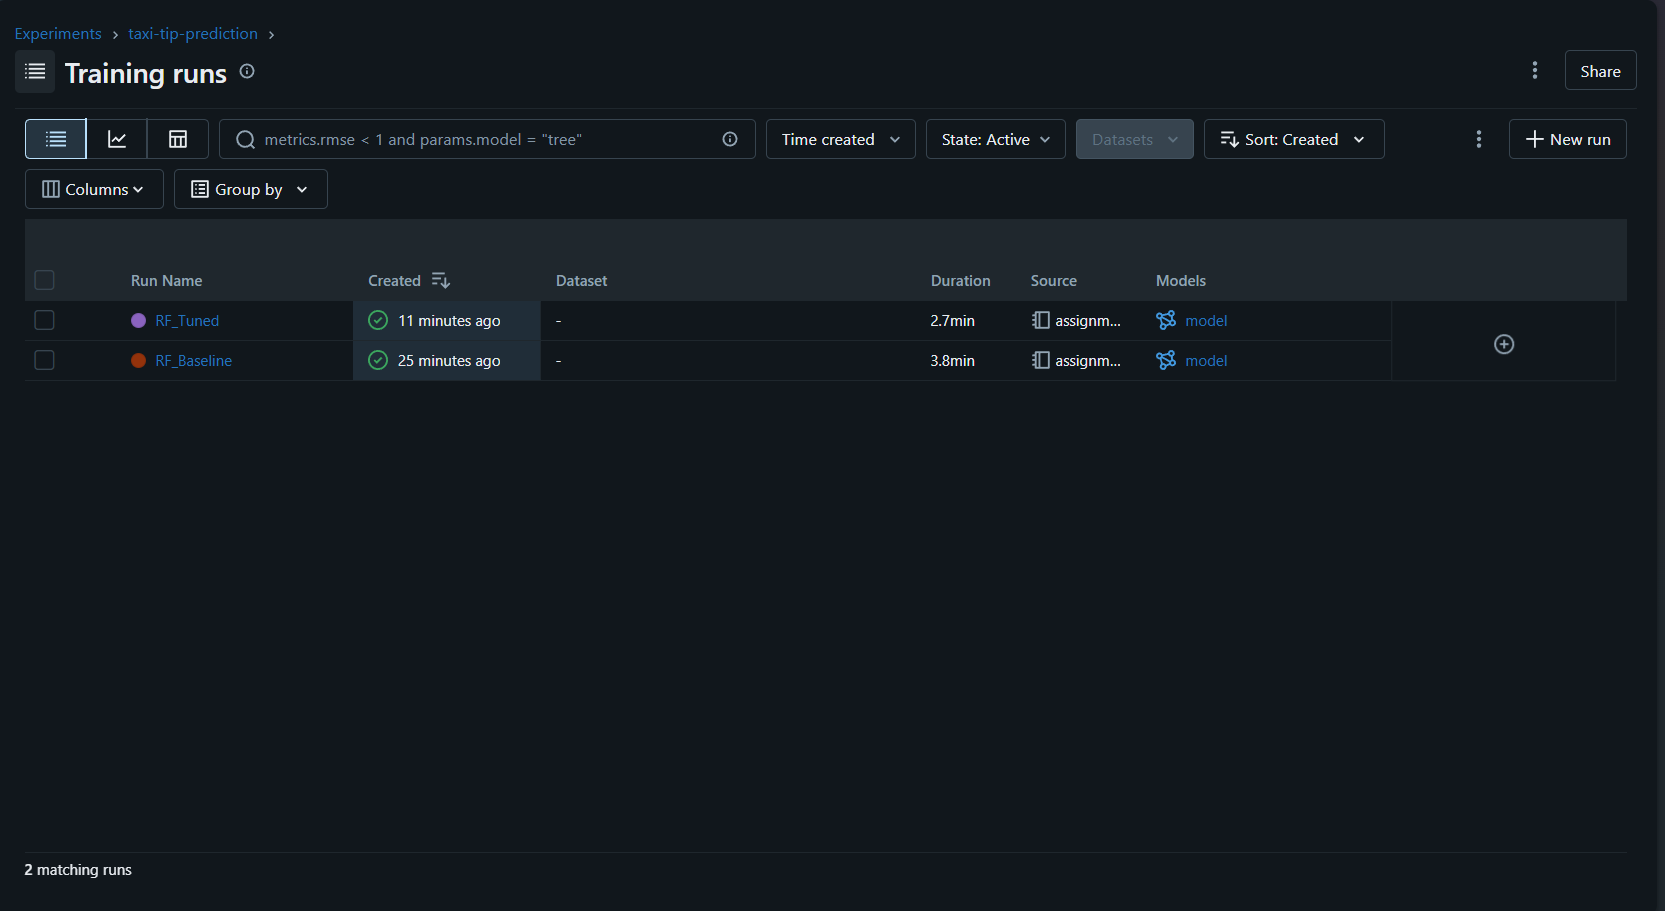

## Task 1.2: Model Comparison and Registry

The two runs are fetched via the MLflow API and displayed side by side. The best model is then registered in the Model Registry with a descriptive name and a version description that records its test-set performance.

In [15]:
client  = MlflowClient()
exp     = client.get_experiment_by_name("taxi-tip-prediction")
runs_df = mlflow.search_runs(experiment_ids=[exp.experiment_id])

compare_cols = ["tags.mlflow.runName", "metrics.MAE", "metrics.RMSE", "metrics.R2"]
print("Side-by-side run comparison:")
print(runs_df[compare_cols].to_string(index=False))

Side-by-side run comparison:
tags.mlflow.runName  metrics.MAE  metrics.RMSE  metrics.R2
           RF_Tuned       1.1941        2.2707      0.6427
        RF_Baseline       1.1823        2.2675      0.6437


**Model Selection Rationale**

The baseline Random Forest outperforms the tuned variant across all three metrics on the held-out test set (MAE 1.1823 vs 1.1941, RMSE 2.2675 vs 2.2707, R² 0.6437 vs 0.6427). The differences are marginal, suggesting the randomised search did not find a meaningfully better configuration. The baseline model is therefore selected for deployment as it achieves the best measured generalisation performance.

In [ ]:
REGISTRY_NAME = "taxi-tip-regressor"

result = mlflow.register_model(
    model_uri=f"runs:/{RUN_BASE_ID}/model",
    name=REGISTRY_NAME
)

client.update_registered_model(
    name=REGISTRY_NAME,
    description="Random Forest Regressor trained on NYC Yellow Taxi Jan 2024 to predict tip_amount."
)

client.update_model_version(
    name=REGISTRY_NAME,
    version=result.version,
    description=(
        f"Tuned RF | MAE={metrics['MAE']:.4f} "
        f"RMSE={metrics['RMSE']:.4f} "
        f"R2={metrics['R2']:.4f} | "
        f"dataset=yellow_tripdata_2024-01"
    )
)

print(f"  registered model : {REGISTRY_NAME}")
print(f"  version          : {result.version}")

### Load Model from Registry and Make a Sample Prediction

The registered model is loaded directly from the MLflow Model Registry and used to predict the tip for a sample trip. This confirms the end-to-end registry workflow.

In [21]:
loaded_model = mlflow.sklearn.load_model(
    model_uri=f"models:/{REGISTRY_NAME}/{result.version}"
)

sample_input = pd.DataFrame([{
    "pickup_hour":             14,
    "pickup_day_of_week":       2,
    "is_weekend":               0,
    "trip_distance":            3.5,
    "trip_duration_minutes":   18.0,
    "trip_speed_mph":          11.7,
    "log_trip_distance":        1.45,
    "fare_amount":             16.5,
    "fare_per_mile":            4.71,
    "fare_per_minute":          0.92,
    "passenger_count":          1,
    "pickup_borough_encoded":   3,
    "dropoff_borough_encoded":  3,
    "tolls_amount":             0.0,
    "extra":                    0.5,
    "mta_tax":                  0.5,
    "congestion_surcharge":     2.5,
    "Airport_fee":              0.0,
}])

sample_scaled = feat_scaler.transform(sample_input[FEATURES])
sample_pred   = loaded_model.predict(sample_scaled)[0]

print(f"Sample input  : trip_distance=3.5 mi, fare_amount=$16.50")
print(f"Predicted tip : ${sample_pred:.2f}")

Sample input  : trip_distance=3.5 mi, fare_amount=$16.50
Predicted tip : $3.06


---

# Part 2: Model Serving with FastAPI

In [22]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(rf_base, "models/rf_baseline.pkl")
joblib.dump(feat_scaler, "models/scaler.pkl")
print("Model and scaler saved to models/")

Model and scaler saved to models/


## Task 2.3: API Testing 

Run all tests and include the output showing all tests passing

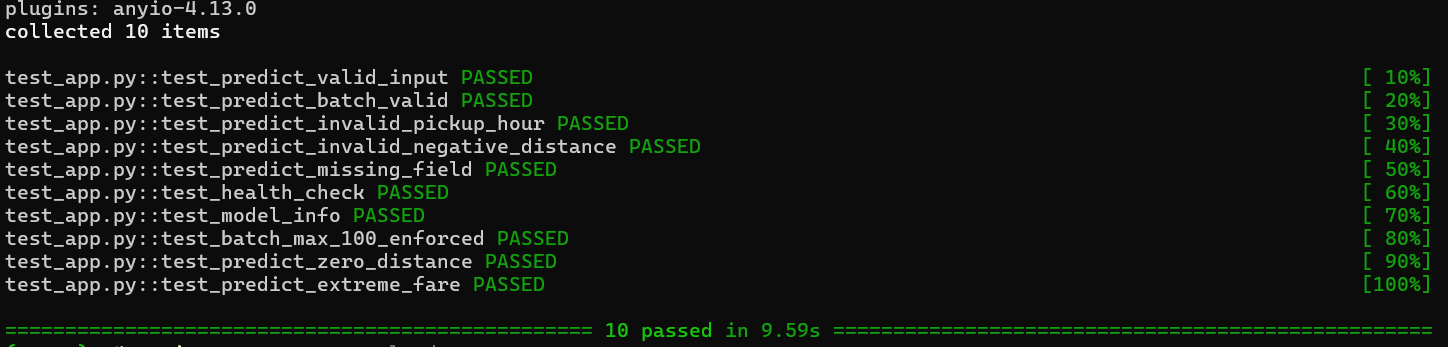


Verifing the auto-generated Swagger UI documentation at /docs is accessible
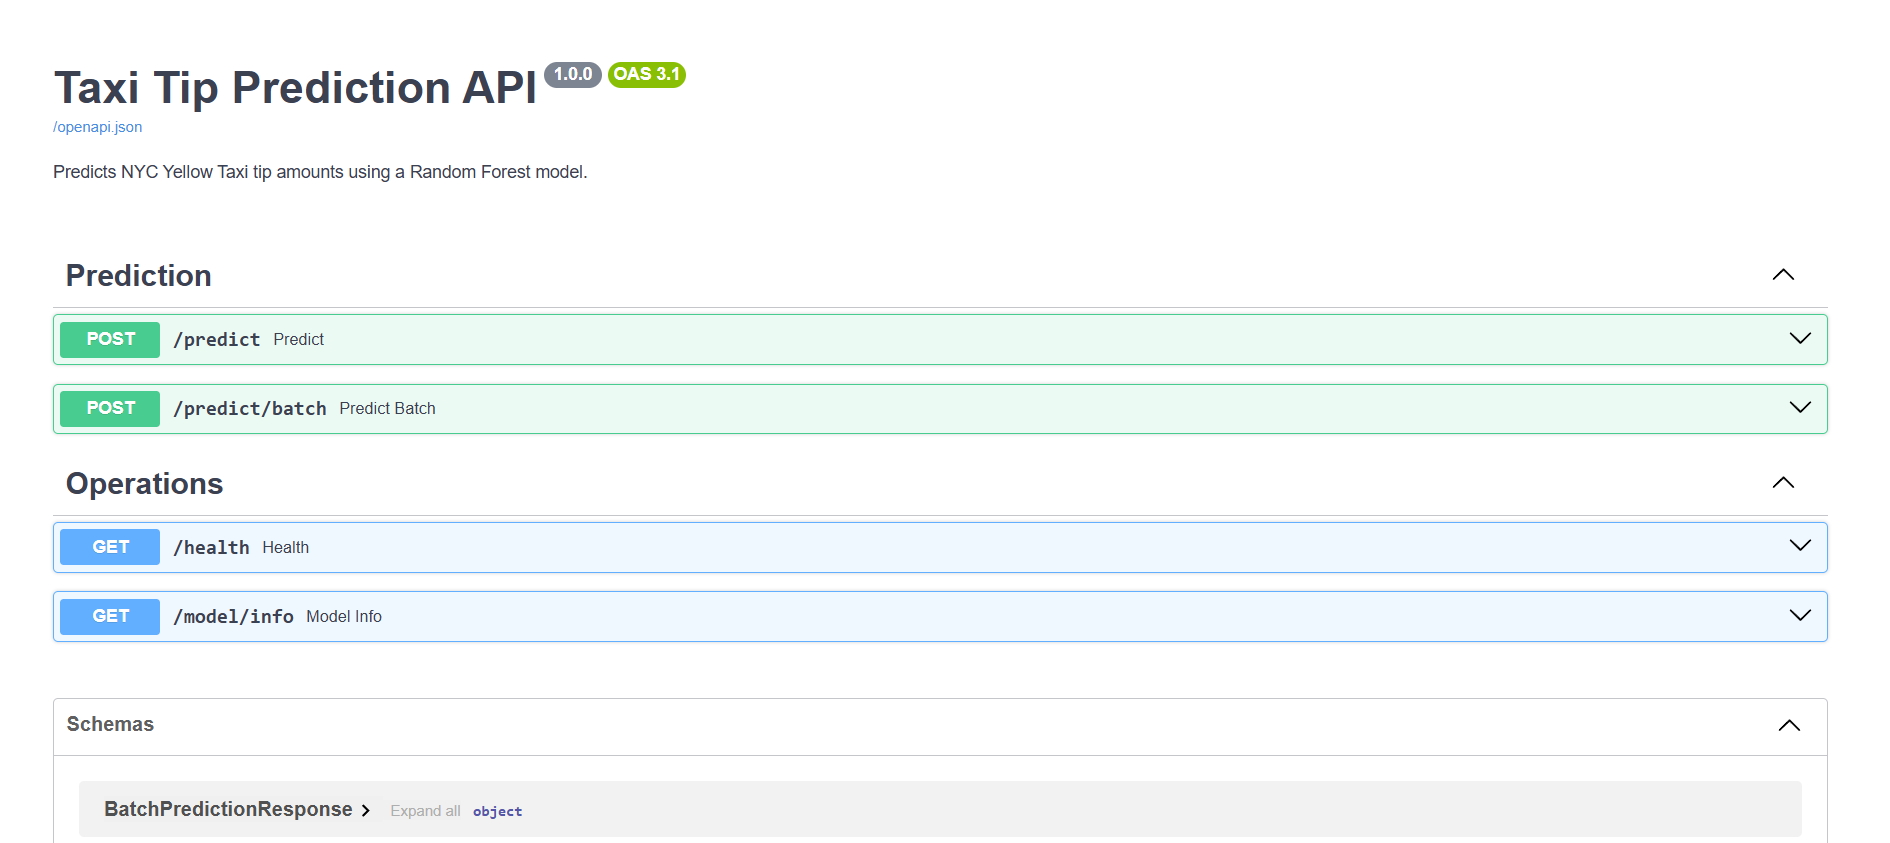

---

# Part 3: Containerization with Docker

### Task 3.1: Dockerfile & Image Building

#### Report image size

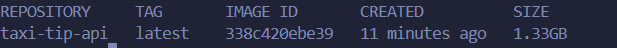

### Task 3.2: Docker Compose & Deployment Demo 

#### Start services with docker compose up

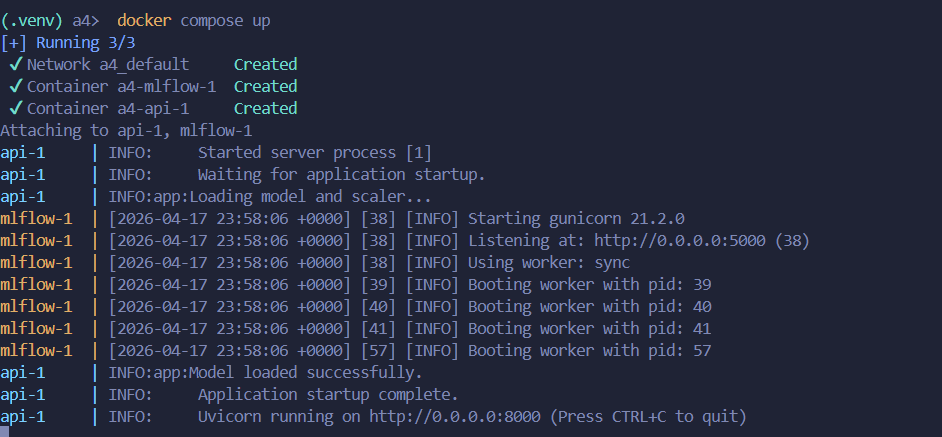

#### Batch Prediction Demo

Three trips were sent in a single `POST /predict/batch` request to the containerized API:

1. **Short city trip** - 1.2 miles, 8 minutes, morning weekday, low fare ($7.50)
   
2. **Airport run** - 18.5 miles, 42 minutes, early morning, high fare ($58.00) with tolls
   
3. **Weekend night trip** - 5.8 miles, 22 minutes, late Saturday night, 3 passengers

The API returned a predicted tip amount and unique `prediction_id` for each trip in a single response.

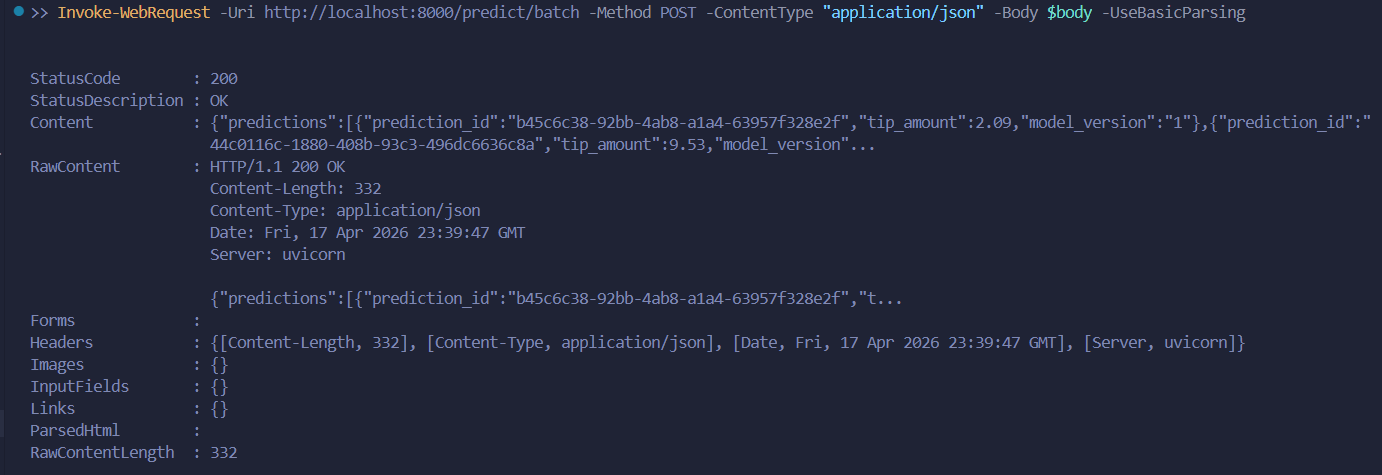

#### Same requests but with /predict for 1 request at a time
1. **Short city trip** - 1.2 miles, 8 minutes, morning weekday, low fare ($7.50)

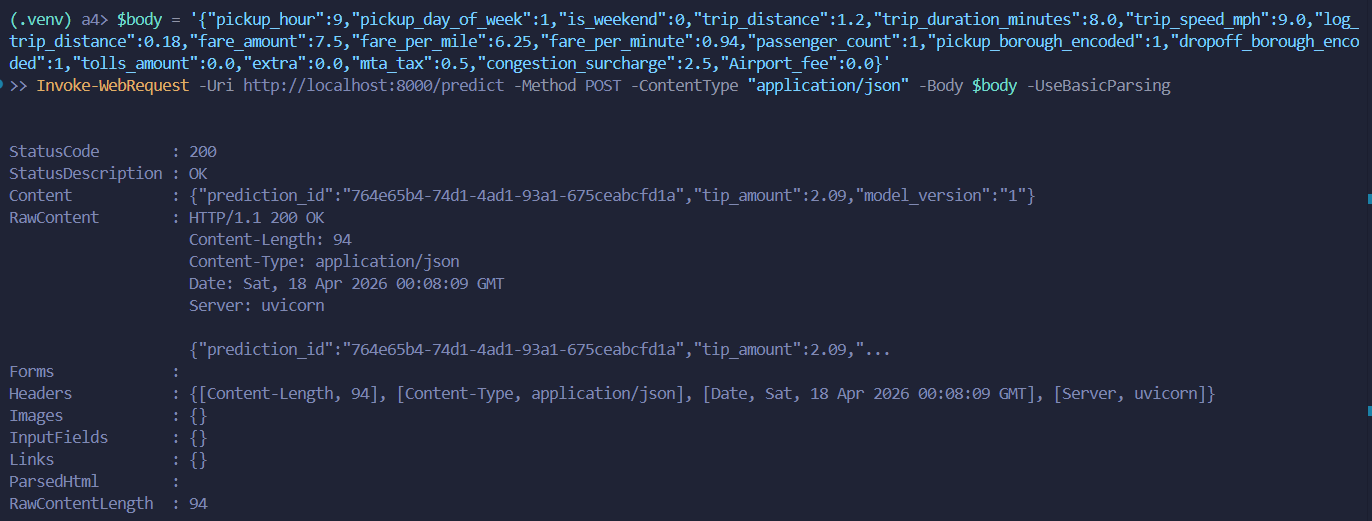

2. **Airport run** - 18.5 miles, 42 minutes, early morning, high fare ($58.00) with tolls

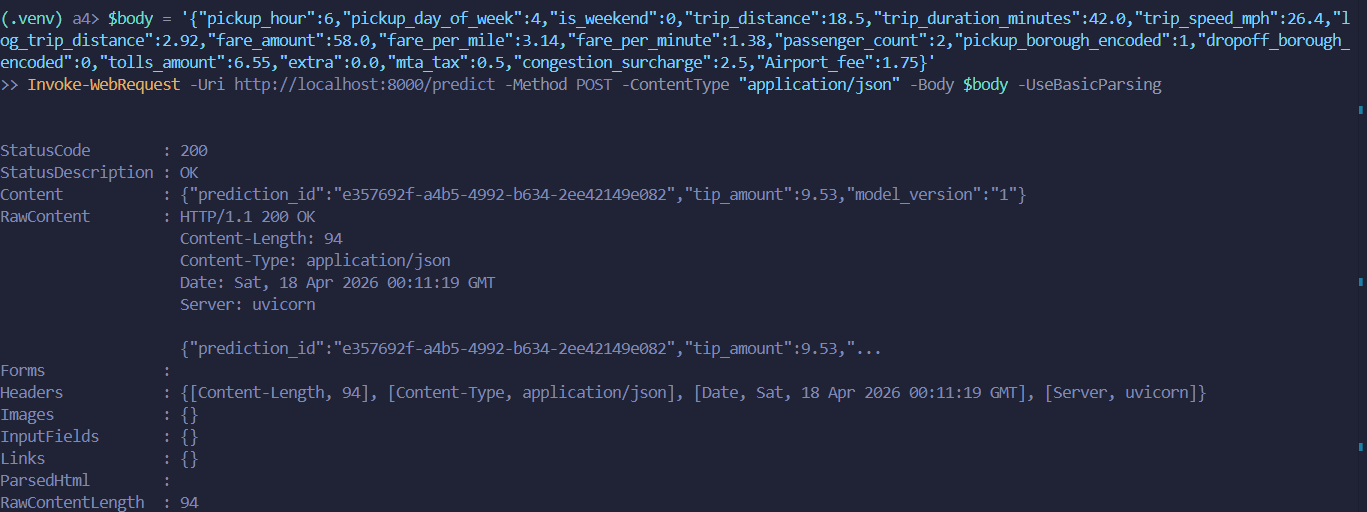

3. **Weekend night trip** - 5.8 miles, 22 minutes, late Saturday night, 3 passengers

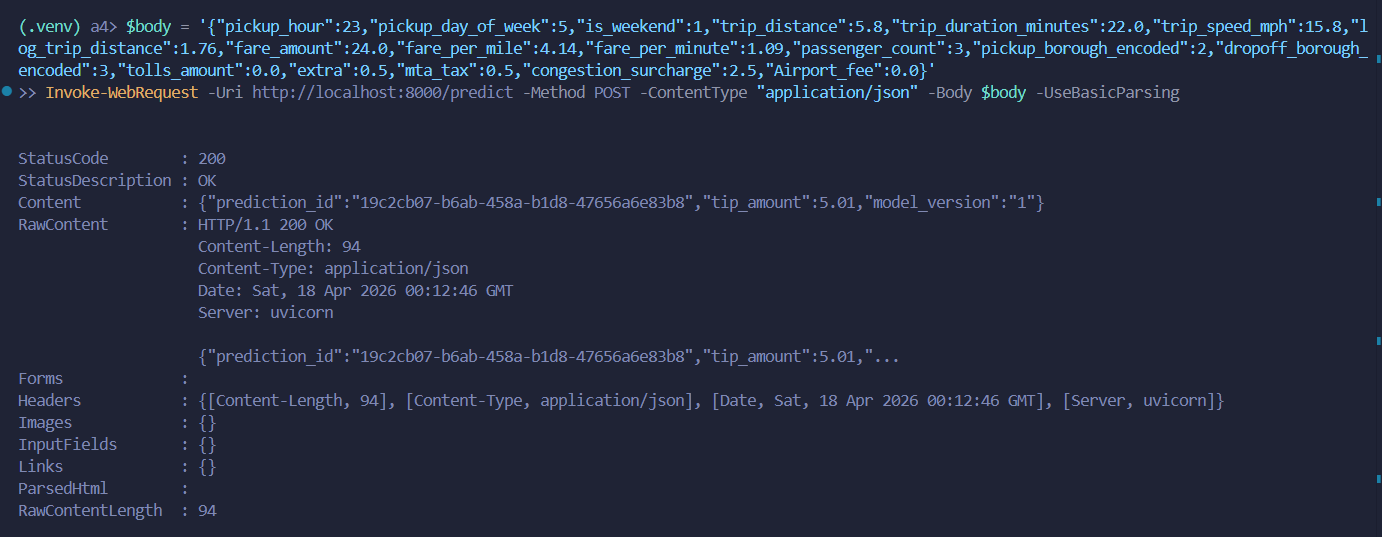

#### Shut down cleanly with docker compose down

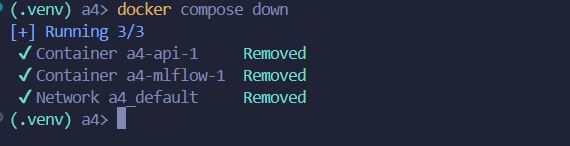

---

# AI Tools Used

Co-pilot was used to assist with this assignment in the following ways:

1. Troubleshooting and verify testing.
2. Formatting README.md.